In [78]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
from sklearn.tree import DecisionTreeRegressor

In [79]:
try: 
    df=pd.read_csv("Airbnb_Open_Data.csv")
    print("Loaded")
except:
    print("Error")

Loaded


### Problem Statement and Business Goal

In this project, we analyze Airbnb open data to understand which factors influence the price of a listing.  
Our goal is to identify patterns and correlations between price and various features such as room type, location, availability, reviews, and cancellation policy.  
This analysis can help hosts and property managers optimize pricing strategies, improve occupancy rates, and make data-driven decisions to increase revenue.

The dataset was taken from a public source on Kaggle, under the name "Airbnb Open Data", and contains information on over 100,000 listings.

The target variable in this analysis is ⁠ price ⁠, which represents the nightly cost of an Airbnb listing.  
We aim to explore how different variables affect the price, and uncover trends or relationships that explain pricing behavior.

### Dataset Dimensions

The dataset contains 102,599 rows and 12 columns.  
Each row represents a unique Airbnb listing, and each column provides information about that listing (such as location, price, and availability).

In [80]:
df.shape

(102599, 12)

### Column Descriptions

•⁠  ⁠*host name*: The name of the person hosting the listing.
•⁠  ⁠*neighbourhood group*: The broader geographical area in which the listing is located (e.g., Brooklyn, Manhattan).
•⁠  ⁠*country*: The country where the listing is located (e.g., United States).
•⁠  ⁠*cancellation_policy*: The type of cancellation policy applied to the listing (e.g., flexible, moderate, strict).
•⁠  ⁠*room type*: The type of room offered (e.g., Entire home/apt, Private room, Shared room).
•⁠  ⁠*Construction year*: The year in which the property was built.
•⁠  ⁠*price*: The nightly price of the listing (this is the target variable).
•⁠  ⁠*service fee*: The additional fee charged by the platform for the booking.
•⁠  ⁠*minimum nights*: The minimum number of nights a guest is required to stay.
•⁠  ⁠*number of reviews*: Total number of reviews received for the listing.
•⁠  ⁠*review rate number*: The average rating score given by guests (typically on a scale from 1 to 5).
•⁠  ⁠*availability 365*: The number of days the listing is available to be booked throughout the year.

In [81]:
df.columns

Index(['host name', 'neighbourhood group', 'country', 'cancellation_policy',
       'room type', 'Construction year', 'price', 'service fee',
       'minimum nights', 'number of reviews', 'review rate number',
       'availability 365'],
      dtype='object')

### Dataset Structure and Missing Values

Using the ⁠ .info() ⁠ function, we examine the structure of the dataset.  
This allows us to see the number of non-null values in each column, the data types, and identify missing data that may need to be cleaned or handled later.

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   host name            102193 non-null  object 
 1   neighbourhood group  102570 non-null  object 
 2   country              102067 non-null  object 
 3   cancellation_policy  102523 non-null  object 
 4   room type            102599 non-null  object 
 5   Construction year    102385 non-null  float64
 6   price                102352 non-null  object 
 7   service fee          102326 non-null  object 
 8   minimum nights       102190 non-null  float64
 9   number of reviews    102416 non-null  float64
 10  review rate number   102273 non-null  float64
 11  availability 365     102151 non-null  float64
dtypes: float64(5), object(7)
memory usage: 9.4+ MB


### Statistical Summary of Numerical Columns

The ⁠ .describe() ⁠ function provides summary statistics for the numerical columns in the dataset.  
We can observe measures such as mean, standard deviation, minimum and maximum values, and quartiles (25%, 50%, 75%).  
These insights help us detect possible outliers and understand the distribution of each variable.

In [83]:
df.describe()

,Construction year,minimum nights,number of reviews,review rate number,availability 365
count,102385.000000,102190.000000,102416.000000,102273.000000,102151.000000
mean,2012.487464,8.135845,27.483743,3.279106,141.133254
std,5.765556,30.553781,49.508954,1.284657,135.435024
min,2003.000000,-1223.000000,0.000000,1.000000,-10.000000
25%,2007.000000,2.000000,1.000000,2.000000,3.000000
50%,2012.000000,3.000000,7.000000,3.000000,96.000000
75%,2017.000000,5.000000,30.000000,4.000000,269.000000
max,2022.000000,5645.000000,1024.000000,5.000000,3677.000000


### Removing Invalid Rows with Negative Values

We remove rows where ⁠ minimum nights ⁠ or ⁠ availability 365 ⁠ had negative values, as these are not logically valid.  
After filtering, we re-run the ⁠ .describe() ⁠ function to observe the updated summary statistics and ensure the data is cleaner for further analysis.

In [84]:
values_number=df.select_dtypes(include=np.number)
columns_with_negatives=(values_number<0).any()
columns_with_negatives

Construction year     False
minimum nights         True
number of reviews     False
review rate number    False
availability 365       True
dtype: bool

In [85]:
df = df[(df['minimum nights'] >= 0) & (df['availability 365'] >= 0)]
df.describe()

,Construction year,minimum nights,number of reviews,review rate number,availability 365
count,101141.000000,101325.000000,101199.000000,101027.000000,101325.000000
mean,2012.486974,8.129386,27.349252,3.280004,141.639882
std,5.763265,28.341661,49.137277,1.283962,135.391349
min,2003.000000,1.000000,0.000000,1.000000,0.000000
25%,2007.000000,2.000000,1.000000,2.000000,4.000000
50%,2012.000000,3.000000,7.000000,3.000000,98.000000
75%,2017.000000,5.000000,30.000000,4.000000,269.000000
max,2022.000000,5645.000000,1024.000000,5.000000,3677.000000


### Missing Values Overview

An analysis of missing values was performed for each column.  
Given that the proportion of missing data is minimal relative to the size of the dataset, it was deemed appropriate to remove these rows without compromising the integrity of the analysis.

In [86]:
df.isnull().sum()

host name              391
neighbourhood group     17
country                523
cancellation_policy     67
room type                0
Construction year      184
price                  246
service fee            271
minimum nights           0
number of reviews      126
review rate number     298
availability 365         0
dtype: int64

In [87]:
df.dropna(inplace=True)

In [88]:
df.isnull().sum()

host name              0
neighbourhood group    0
country                0
cancellation_policy    0
room type              0
Construction year      0
price                  0
service fee            0
minimum nights         0
number of reviews      0
review rate number     0
availability 365       0
dtype: int64

### Unique Values in Categorical Columns

The following series display all unique values found in each of the categorical columns.  
This helps us better understand the data structure and possible categories:
•⁠  ⁠⁠ neighbourhood group ⁠
•⁠  ⁠⁠ country ⁠
•⁠  ⁠⁠ cancellation_policy ⁠
•⁠  ⁠⁠ room type ⁠

In [89]:
pd.Series(df["neighbourhood group"].unique())

0         Brooklyn
1        Manhattan
2          brookln
3            Bronx
4           Queens
5    Staten Island
dtype: object

In [90]:
pd.Series(df["country"].unique())

0    United States
dtype: object

In [91]:
pd.Series(df["cancellation_policy"].unique())

0      strict
1    moderate
2    flexible
dtype: object

In [92]:
pd.Series(df["room type"].unique())

0       Private room
1    Entire home/apt
2        Shared room
3         Hotel room
dtype: object

In [93]:
df["neighbourhood group"].value_counts()

neighbourhood group
Manhattan        42369
Brooklyn         40568
Queens           12867
Bronx             2621
Staten Island      919
brookln              1
Name: count, dtype: int64

In [94]:
df['neighbourhood group'] = df['neighbourhood group'].replace({'brookln': 'Brooklyn'})
df["neighbourhood group"].value_counts()

neighbourhood group
Manhattan        42369
Brooklyn         40569
Queens           12867
Bronx             2621
Staten Island      919
Name: count, dtype: int64

In [95]:
df['price'] = df['price'].replace({'[$,]': ''}, regex=True).astype(float)
df['service fee'] = df['service fee'].replace({'[$,]': ''}, regex=True).astype(float)

In [96]:
df.groupby("cancellation_policy")[["price", "review rate number"]].mean()

,price,review rate number
cancellation_policy,,
flexible,627.117510,3.280036
moderate,625.268160,3.280427
strict,624.329615,3.278609


Text(0, 0.5, 'price')

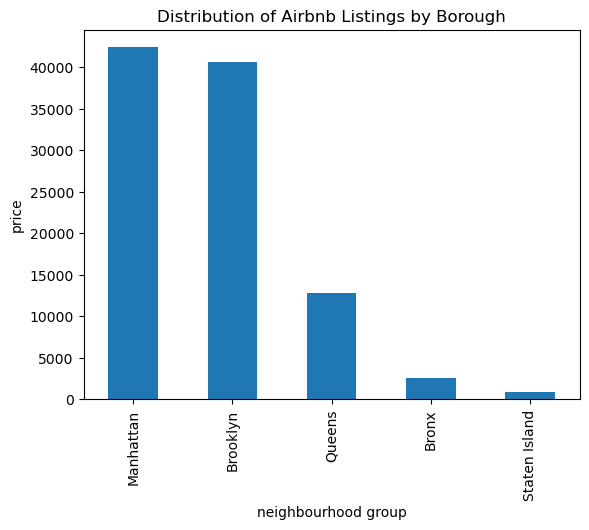

In [97]:
df["neighbourhood group"].value_counts().plot(kind='bar')
plt.title("Distribution of Airbnb Listings by Borough")
plt.ylabel("price")

In [98]:
df['price'] = df['price'].replace({'[$,]': ''}, regex=True).astype(float)
df['service fee'] = df['service fee'].replace({'[$,]': ''}, regex=True).astype(float)

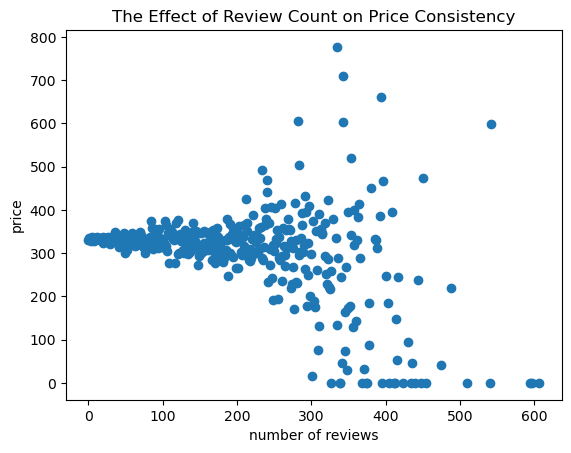

In [99]:
price_std = df.groupby("number of reviews")["price"].std()
plt.scatter(price_std.index, price_std.values)
plt.ylabel("price")
plt.xlabel("number of reviews")
plt.title("The Effect of Review Count on Price Consistency")
plt.show()

Text(0.5, 1.0, 'Price Standard Deviation for Each Rating')

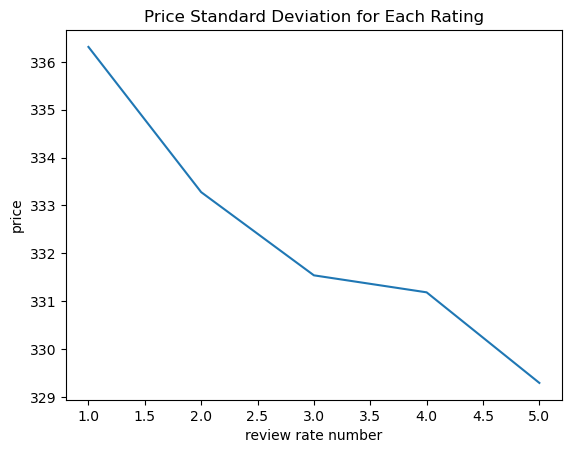

In [100]:
df.groupby("review rate number")["price"].std().plot()
plt.ylabel("price")
plt.title("Price Standard Deviation for Each Rating")

Text(0.5, 1.0, 'How Construction Year Affects Price Variability')

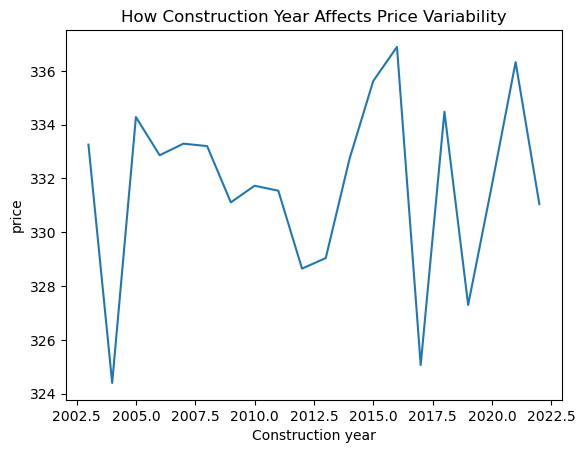

In [101]:
df.groupby("Construction year")["price"].std().plot()
plt.ylabel("price")
plt.title("How Construction Year Affects Price Variability")

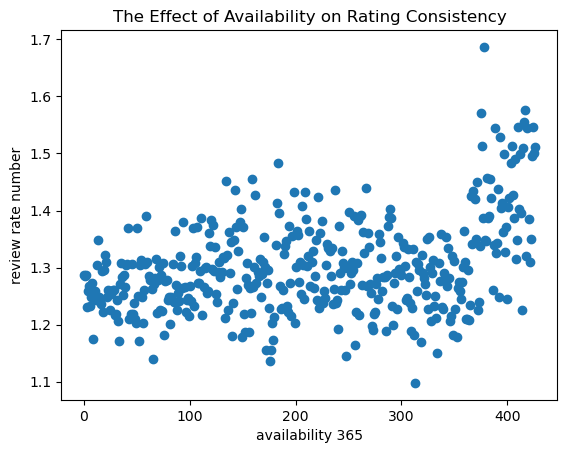

In [102]:
price_std = df.groupby("availability 365")["review rate number"].std()
plt.scatter(price_std.index, price_std.values)
plt.ylabel("review rate number")
plt.xlabel("availability 365")
plt.title("The Effect of Availability on Rating Consistency")
plt.show()

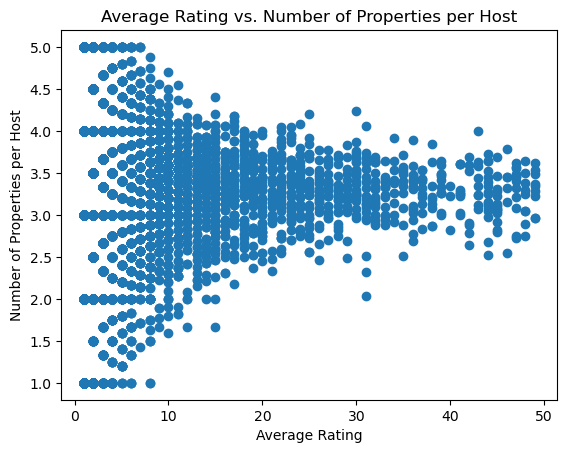

In [103]:
property_counts=df.value_counts("host name")
avg_rating=df.groupby("host name")["review rate number"].mean()
host_data = pd.DataFrame({'property_count': property_counts, 'avg_rating': avg_rating})
filtered_data = host_data[host_data['property_count'] < 50] 
plt.scatter(x=filtered_data['property_count'], y=filtered_data['avg_rating'])
plt.ylabel("Number of Properties per Host")
plt.xlabel("Average Rating")
plt.title("Average Rating vs. Number of Properties per Host")
plt.show()

Text(0.5, 1.0, 'Market Dynamics: The Effect of Location and Room Type on Price')

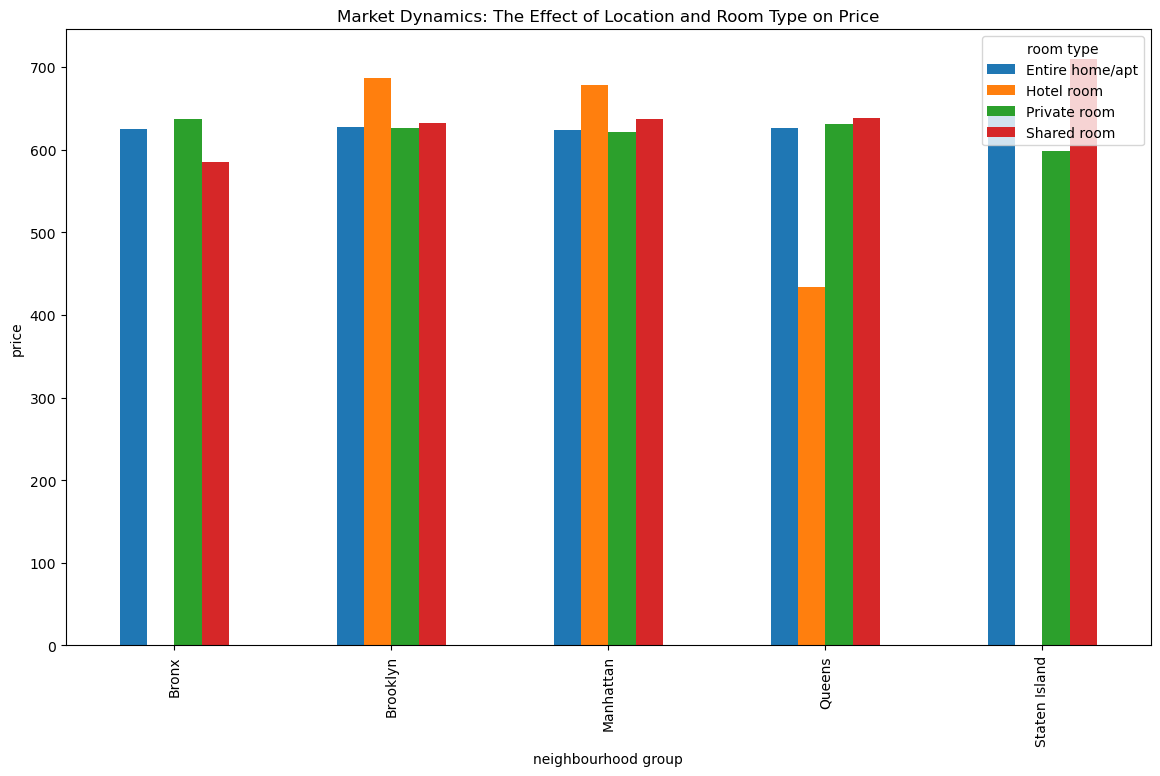

In [104]:
df.groupby(['neighbourhood group', 'room type'])['price'].mean().unstack().plot(kind='bar', figsize=(14, 8))
plt.ylabel("price")
plt.title("Market Dynamics: The Effect of Location and Room Type on Price")


In [105]:
array_price=np.array(df["price"].copy())
array1=np.random.randint(low=1,high=1000000,size=10000)
array2=np.random.randint(low=1,high=1000000,size=100000)
array3=np.random.randint(low=1,high=1000000,size=1000000)

In [106]:
arrays_to_test = {
    "array_price":array_price,
    "Random Array (10k)": array1,
    "Random Array (100k)": array2,
    "Random Array (1m)": array3,
}

In [107]:
def bubble_sort(lst):
    for i in range(len(lst)):
        for j in range(len(lst)-1):
            if lst[j] > lst[j+1]:
                lst[j],lst[j+1] = lst[j+1],lst[j]

In [108]:
%%time
def function():
    total=0
    for i in range(50):
        tital+=1
    return total

CPU times: user 1 μs, sys: 0 ns, total: 1 μs
Wall time: 3.1 μs


In [109]:
%%time
bubble_sort(array1)

CPU times: user 12.3 s, sys: 23.1 ms, total: 12.4 s
Wall time: 12 s


In [110]:
'''%%time
bubble_sort(array2)'''

'%%time\nbubble_sort(array2)'

In [111]:
'''%%time
bubble_sort(array3)'''

'%%time\nbubble_sort(array3)'

In [112]:
'''%%time
bubble_sort(array_price)'''

'%%time\nbubble_sort(array_price)'

In [113]:
%%time
np.sort(array_price)

CPU times: user 4.43 ms, sys: 879 μs, total: 5.31 ms
Wall time: 4.68 ms


array([  50.,   50.,   50., ..., 1200., 1200., 1200.])

In [114]:
%%time
np.sort(array1)

CPU times: user 130 μs, sys: 26 μs, total: 156 μs
Wall time: 123 μs


array([    15,     26,     49, ..., 999857, 999957, 999981])

In [115]:
%%time
np.sort(array2)

CPU times: user 4.15 ms, sys: 671 μs, total: 4.82 ms
Wall time: 4.02 ms


array([    28,     56,     58, ..., 999976, 999994, 999995])

In [116]:
%%time
np.sort(array3)

CPU times: user 42.6 ms, sys: 1.81 ms, total: 44.4 ms
Wall time: 43.3 ms


array([     1,      1,      2, ..., 999992, 999993, 999994])

In [117]:
len(array_price)

99345

In [118]:
time_run_numpy=['4.25','196 us','4.71 ms', '47.1 ms']
time_run_bubble=['20 m','12.3 s','20 m', 'more than 24 h']
size=[99345, 10000, 100000, 1000000]
index=['array_price','Random Array (10k)','Random Array (100k)','Random Array (1m)']
data_time=pd.DataFrame({"size":size,"Time in Numpy":time_run_numpy,"Time in Bubble":time_run_bubble}, index=index)
data_time

,size,Time in Numpy,Time in Bubble
array_price,99345,4.25,20 m
Random Array (10k),10000,196 us,12.3 s
Random Array (100k),100000,4.71 ms,20 m
Random Array (1m),1000000,47.1 ms,more than 24 h


Performance Comparison: Bubble Sort vs. NumPy

The results clearly demonstrate a massive performance gap. Bubble Sort is an inefficient algorithm (O(n²) complexity) that becomes extremely slow as the amount of data increases.

In contrast, NumPy's sort function is a highly optimized implementation (average complexity of O(n log n)) written in a fast language (C), making it vastly more efficient.

Conclusion: This comparison proves the critical importance of using built-in functions from specialized libraries like NumPy for efficient data processing.

In [119]:
df["total price"]=df["price"]+df["service fee"]

In [120]:
df['price_relative_to_neighborhood'] = df['price'] / df.groupby('neighbourhood group')['price'].transform('mean')


This code creates a new column by dividing each property's price by the average price of the neighborhood it's in.

The output in the new column is a ratio that symbolizes the property's pricing relative to its local market:

A value greater than 1 means the property is more expensive than its neighborhood's average.

A value less than 1 means it is cheaper than its neighborhood's average.

A value equal to 1 means the property's price is exactly the average for its neighborhood.

In [121]:
host_counts = df['host name'].value_counts()
df['host_property_count']=df['host name'].apply(lambda name:host_counts[name])

This code converts the textual host name column into a new numerical column called host_property_count, where the value for each row is the total number of properties belonging to that row's host

In [122]:
df['host_avg_rating'] = df.groupby('host name')['review rate number'].transform('mean')

This line of code creates a new column named host_avg_rating. For each property (row), the value in this new column is the overall average rating of its host, calculated across all properties that host owns.

In [123]:
df.drop(columns=['host name'],inplace=True)

In [124]:
df_encoded= pd.get_dummies(df)

In [125]:
scaler = MinMaxScaler()

In [126]:
df_final_normalized = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

In [127]:
def get_kmeans_accuracy(data, top_k):
    sum_squared = []
    silhouette = []
    K = range(2, top_k + 1)
    for i in K:
        kmeans = KMeans(n_clusters = i)
        kmeans.fit(data)
        sum_squared.append(kmeans.inertia_) # errors
        silhouette.append(silhouette_score(data, kmeans.labels_))
    return pd.DataFrame({
    "K": K,
    "SSE": sum_squared,
    "SIL": silhouette
  })

In [128]:
result = get_kmeans_accuracy(df_final_normalized, 20) 
result

,K,SSE,SIL
0,2,190609.209194,0.202349
1,3,173516.607893,0.191745
2,4,153662.612737,0.201515
3,5,142559.866998,0.217283
4,6,124373.520670,0.270986
5,7,121877.744503,0.228215
6,8,113058.887315,0.236189
7,9,107769.472966,0.251027
8,10,100219.756984,0.278158
9,11,92655.491754,0.294147


In [129]:
result.set_index("K", inplace=True)
result

,SSE,SIL
K,,
2,190609.209194,0.202349
3,173516.607893,0.191745
4,153662.612737,0.201515
5,142559.866998,0.217283
6,124373.520670,0.270986
7,121877.744503,0.228215
8,113058.887315,0.236189
9,107769.472966,0.251027
10,100219.756984,0.278158


<Axes: xlabel='K'>

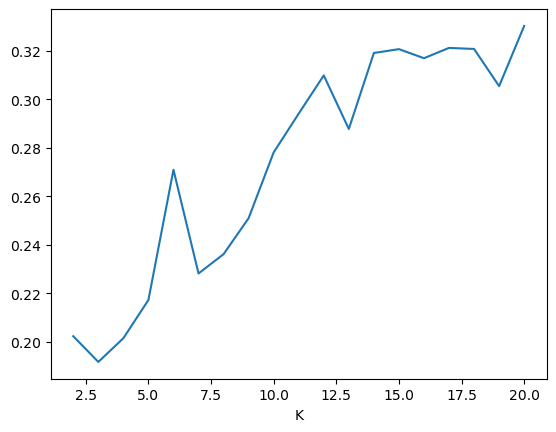

In [130]:
result["SIL"].plot()

<Axes: xlabel='K'>

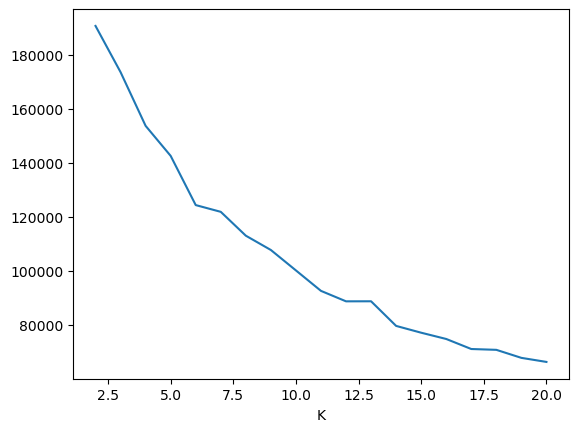

In [131]:
result["SSE"].plot()

In [132]:
kmeans_obj = KMeans(n_clusters =12)
kmeans_obj.fit(df_final_normalized)

KMeans(n_clusters=12)

In [133]:
df_encoded["Cluster"] = kmeans_obj.labels_

In [134]:
df_encoded.groupby("Cluster").mean()

,Construction year,price,service fee,minimum nights,number of reviews,review rate number,availability 365,total price,price_relative_to_neighborhood,host_property_count,...,neighbourhood group_Queens,neighbourhood group_Staten Island,country_United States,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict,room type_Entire home/apt,room type_Hotel room,room type_Private room,room type_Shared room
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2012.359930,623.073966,124.608736,6.174607,29.968084,3.284450,146.328130,747.682702,0.996484,89.691439,...,0.300524,0.018288,1.0,0.000000,1.0,0.000000,0.000000,0.000466,0.988934,0.010600
1,2012.523406,626.494406,125.301781,7.287281,28.263065,3.264169,128.978434,751.796187,0.999312,91.598999,...,0.000000,0.000000,1.0,0.000000,1.0,0.000000,0.490063,0.000074,0.490431,0.019432
2,2012.567875,628.191654,125.640631,7.043600,24.395747,3.287415,136.475458,753.832286,1.001798,87.667781,...,0.000000,0.022068,1.0,1.000000,0.0,0.000000,0.000000,0.000267,0.964825,0.034907
3,2012.475963,623.515835,124.704944,11.985418,20.006835,3.281841,151.500911,748.220779,1.000929,122.666211,...,0.000000,0.000000,1.0,0.000000,0.0,1.000000,0.964912,0.002848,0.000000,0.032240
4,2012.492521,619.202227,123.838038,7.657181,33.453267,3.259701,137.439208,743.040265,0.986952,93.906647,...,0.184794,0.018783,1.0,0.000000,0.0,1.000000,0.994826,0.000000,0.000000,0.005174
5,2012.535967,339.052365,67.811741,11.042943,23.962493,3.293894,151.492843,406.864106,0.543347,110.205834,...,0.146222,0.012865,1.0,0.000000,1.0,0.000000,0.967023,0.003624,0.000000,0.029353
6,2012.446629,626.941464,125.389315,11.522381,20.955126,3.266911,147.964234,752.330779,1.006428,124.380207,...,0.000000,0.000000,1.0,1.000000,0.0,0.000000,0.961679,0.003999,0.000000,0.034322
7,2012.394531,634.226047,126.845095,6.204628,32.759227,3.336393,164.990438,761.071142,1.008005,78.200994,...,1.000000,0.000000,1.0,0.484796,0.0,0.515204,0.000000,0.000956,0.954485,0.044559
8,2012.554654,627.606383,125.520346,6.112234,24.087633,3.283644,136.476596,753.126729,1.000815,84.845878,...,0.000000,0.017420,1.0,0.000000,0.0,1.000000,0.000000,0.000532,0.963165,0.036303


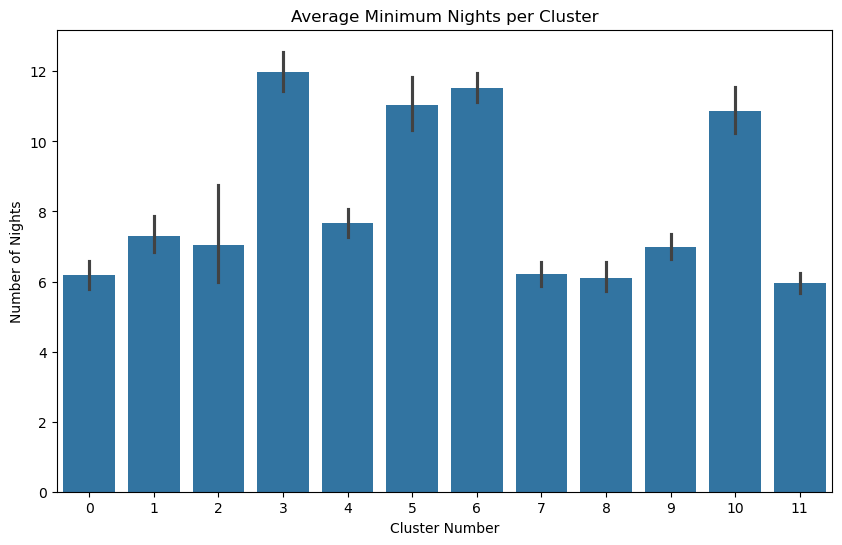

In [135]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_encoded["Cluster"], y=df_encoded['minimum nights'])
plt.title('Average Minimum Nights per Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Nights')
plt.show()

The main conclusion from this graph is that the market is divided into two primary strategies, both within the "Mid-Term" range, with no extreme strategies present.

"Week-Plus" Strategy: One group, including Clusters 0, 2, and 4, requires longer stays of approximately 11 nights. This strategy targets guests looking for rentals of one-and-a-half to two weeks.

"Weekly" Strategy: A second group, including Clusters 3, 5, and 9, offers more flexibility with a minimum stay requirement of about one week (approx. 6 nights).

(100.0, 200.0)

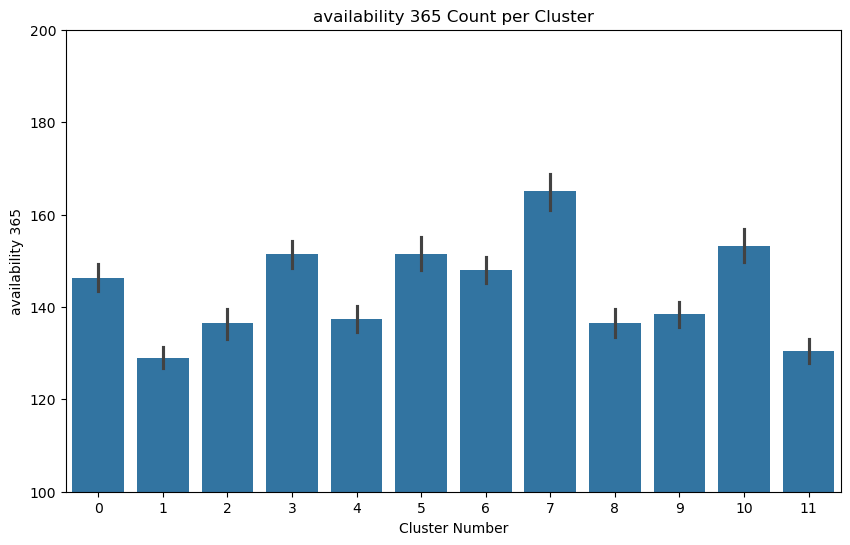

In [136]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_encoded["Cluster"], y=df_encoded['availability 365'])
plt.title('availability 365 Count per Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('availability 365')
plt.ylim(100, 200)

The analysis shows the variation in room availability across the different clusters.

In [137]:
df["Cluster"]=df_encoded["Cluster"]

Text(0.5, 1.0, 'Average Price of Each Cluster by Neighbourhood Group')

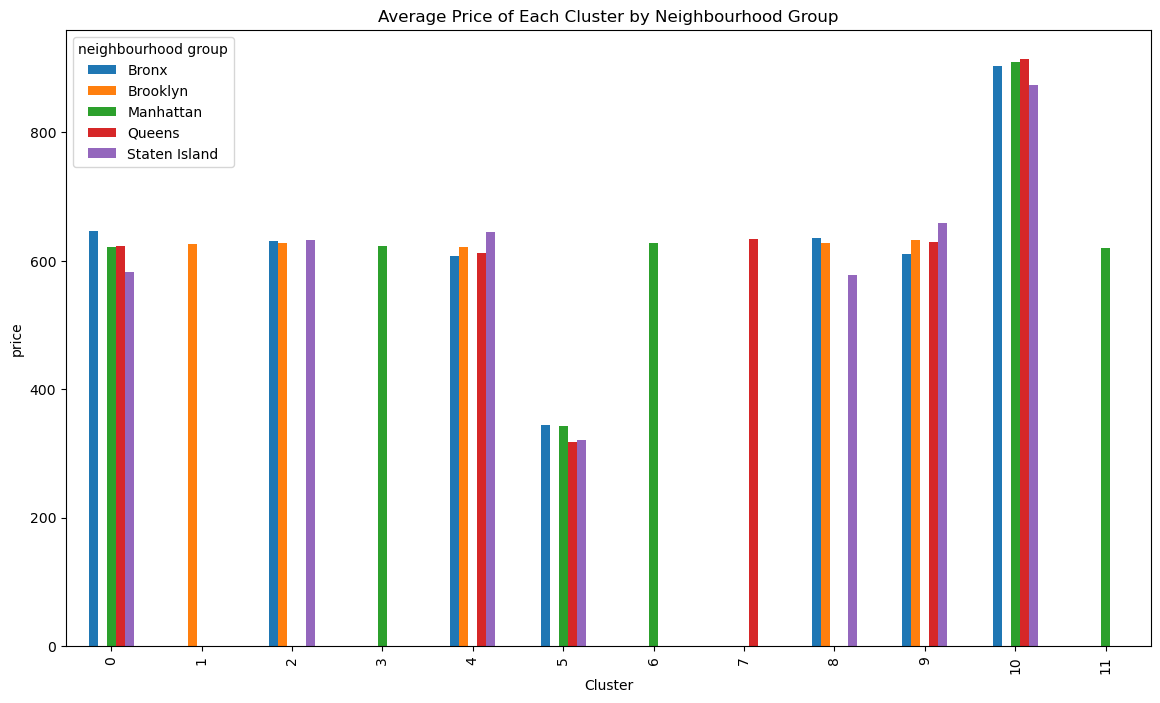

In [138]:

df.groupby(['Cluster','neighbourhood group'])['price'].mean().unstack().plot(kind='bar', figsize=(14, 8))
plt.ylabel('price')
plt.title('Average Price of Each Cluster by Neighbourhood Group')


According to the clustering, we presented several graphs in order to see certain patterns, either between the price and various different categories, or between the property's occupancy and its price.

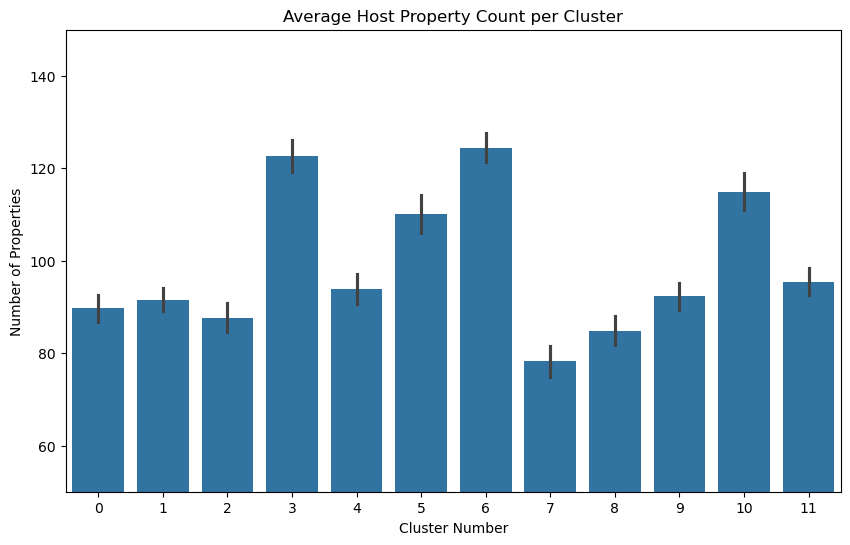

In [139]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_encoded["Cluster"], y=df_encoded['host_property_count'])
plt.title('Average Host Property Count per Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Properties')
plt.ylim(50, 150) 
plt.show()

The graph shows the number of properties each cluster has. It's clear that clusters 2, 5, 7, and 9 are the dominant ones in the market.

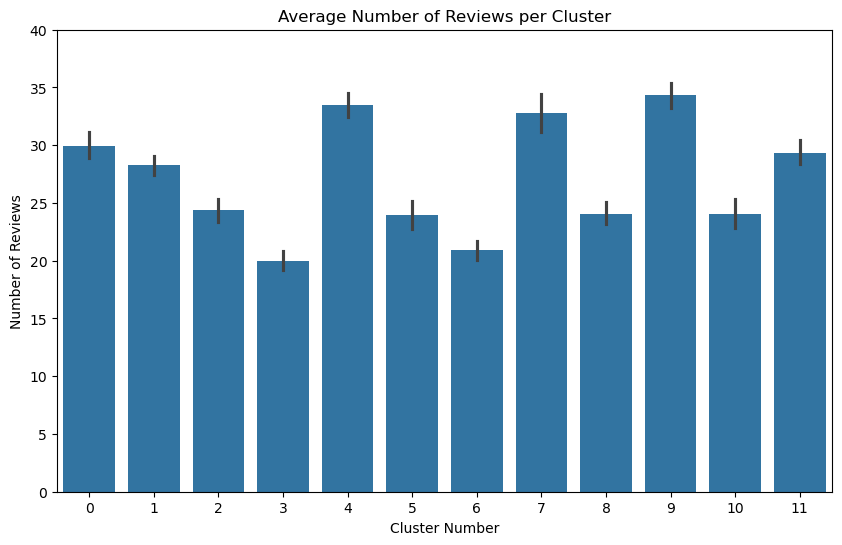

In [140]:
plt.figure(figsize=(10, 6))
plt.title('Average Number of Reviews per Cluster')
sns.barplot(x=df_encoded["Cluster"], y=df_encoded['number of reviews'])
plt.xlabel('Cluster Number')
plt.ylabel('Number of Reviews')
plt.ylim(0,40) 
plt.show()

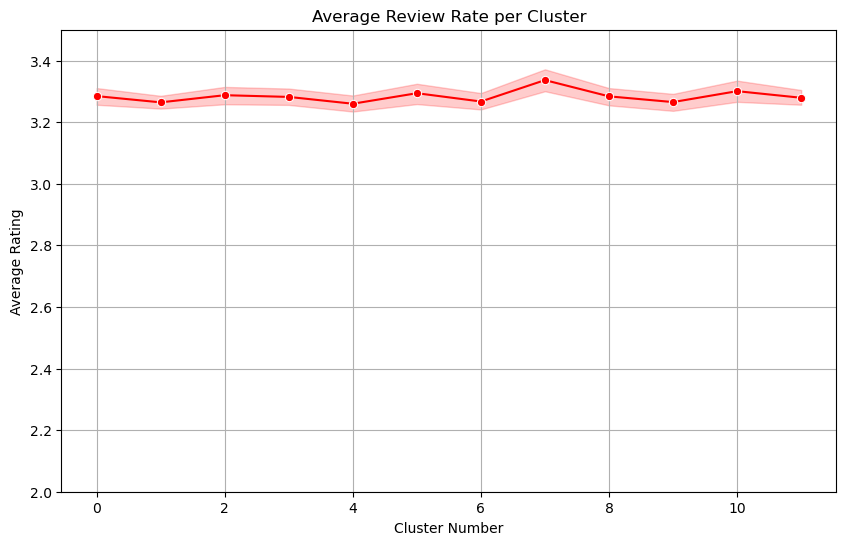

In [141]:
plt.figure(figsize=(10, 6))
plt.title('Average Review Rate per Cluster')
sns.lineplot(x=df_encoded["Cluster"], y=df_encoded['review rate number'], marker='o', color='r')
plt.xlabel('Cluster Number')
plt.ylabel('Average Rating')
plt.ylim(2.0, 3.5) 
plt.grid(True)
plt.show()

In the two graphs above, we see that although groups 1 and 6 have a higher number of ratings than the rest, the average rating remains the same, which seems to supports the quality of those groups

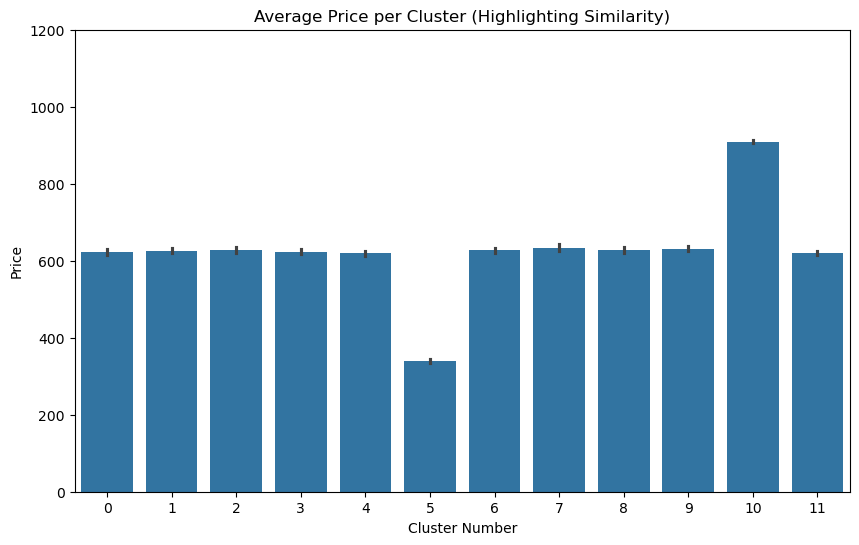

In [142]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_encoded["Cluster"], y=df_encoded['price'])
plt.title('Average Price per Cluster (Highlighting Similarity)')
plt.xlabel('Cluster Number')
plt.ylabel('Price')
plt.ylim(0, 1200) 
plt.show()

The graph clearly illustrates the price distribution, highlighting Cluster 7 as the most expensive and Cluster 9 as the least expensive, while the other clusters are priced in a similar range

# Key Findings from the Analysis

`The market is divided into three different price tiers`: The analysis clearly identified a luxury group, a budget group, and a large group of standard-priced properties.

`The Luxury Group (Cluster 7)`: This group contains the most expensive properties by far, with an average price of around $908. These are run by large, professional hosts.

`The Budget Group (Cluster 9)`: This group offers the cheapest properties, with an average price of around $340. These are also run by large, professional hosts.

`An Unsuccessful Strategy (Cluster 11)`: This group represents smaller hosts who charge a relatively high price (around $631) and, as a result, have the lowest occupancy.

`The Most In-Demand Properties (Clusters 0 & 3)`: In the standard price range (around $624-$630), these two groups are the most successful. They have the highest occupancy, meaning they are booked most frequently.

(9500.0, 11000.0)

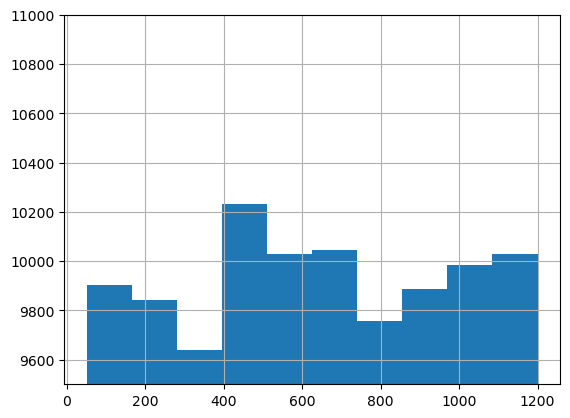

In [143]:
df_encoded["price"].hist()
plt.ylim(9500,11000)

In [144]:
def categorize_price(price):
  if price <= 400:
    return 'low'
  elif price <= 800:
    return 'Mid'
  else:
    return 'high'

In [145]:
df_predict=pd.DataFrame(df_encoded)
df_predict["price_category"]=df_predict['price'].apply(categorize_price)

In [146]:
df_predict["price_category"]

0         high
1          low
2          Mid
3          low
4          low
          ... 
102594    high
102595    high
102596    high
102597     Mid
102598    high
Name: price_category, Length: 99345, dtype: object

In [147]:
columns_to_drop = ['price', 'total price', 'service fee', 'price_relative_to_neighborhood']
x = df_final_normalized.drop(columns=columns_to_drop)
y = df_predict["price_category"]

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25)

In [148]:
print("Train", x_train.shape,  "Test",  x_test.shape)

Train (74508, 20) Test (24837, 20)


In [149]:
tree = DecisionTreeClassifier()
tree.fit(x_train,y_train)
y_pred = tree.predict(x_test)
print("Accuracy", metrics.accuracy_score(y_test, y_pred))

Accuracy 0.5778475661311753


In [150]:
feature_importances_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': tree.feature_importances_
})

sorted_df = feature_importances_df.sort_values(by='Importance', ascending=False)

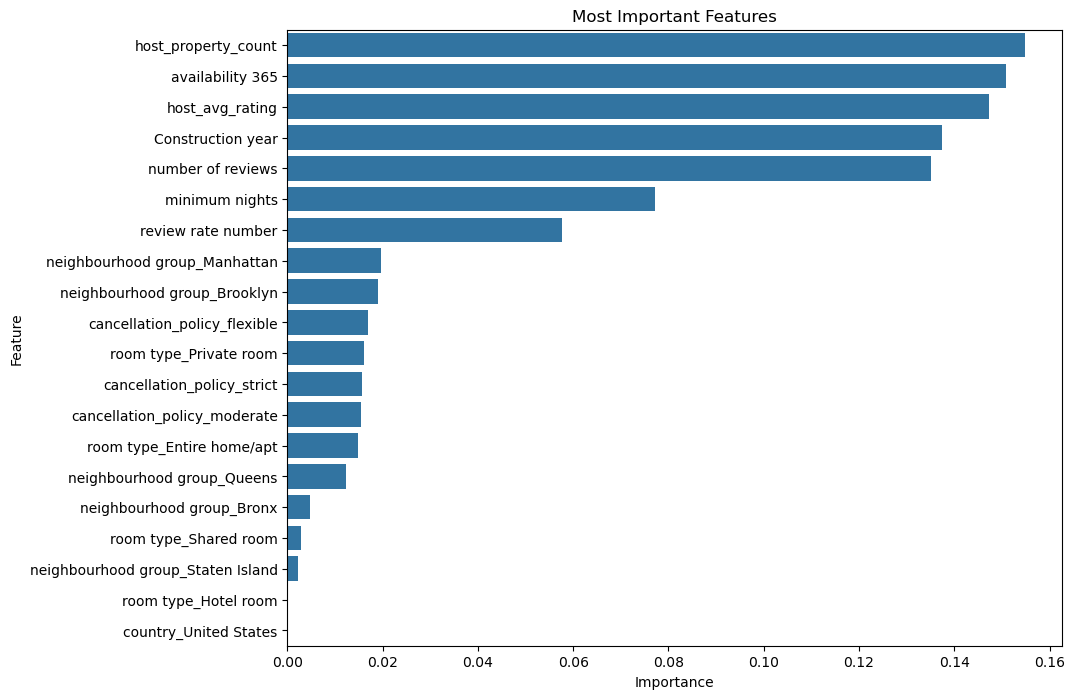

In [153]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=sorted_df)
plt.title('Most Important Features')
plt.show()

# Three Key Insights from the Model's Results


`How the property is run matters most`.
The most important factors for predicting a property's price category is the availability and the number of reviews it has. This means the model cares more about how popular and busy the property is right now than its fixed features.

`The host's details directly affect the price category`.
sector like the host's average rating and the number of properties they own are also very important. This shows that the model learned the host's reputation and size (whether they are a small host or a big company) are key factors in setting the price.

`The general location is less important`.
Surprisingly, the property's borough (Manhattan, Brooklyn, etc.) is ranked very low in importance. This suggests that for determining the price category, knowing the property's availability and host rating is more useful than knowing which borough it's in.